# Modelos de regresión linea para la tasa de incidencia delictiva

En esta notebook se construyen modelos de regresión lineal con el objetivo de analizar e interpretar el impacto de variables socioeconómicas sobre la tasa de delitos, incorporando de forma progresiva variables de urbanización y geografía como factores de control.

Se busca:

- Identificar variables explicativas relevantes
- Evaluar la estabilidad de los coeficientes al introducir variables de control
- Medir el impacto de la urbanización y la geografía en el modelo
- Comparar modelos lineales y regularizados (Lasso)

Se utiliza el dataset [geospatial](../docs/data/dataset_geospatial.md) como fuente única, construyendo distintos subsets de variables para analizar cómo cambian los resultados bajo diferentes niveles de control.

## Setup

In [1]:
import os

In [138]:
from collections import defaultdict

In [150]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import dotenv

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso 
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [92]:
import mlflow

In [4]:
from incidencia_delictiva.config import PROCESSED_DATA_DIR as processed_dir
from incidencia_delictiva.config import PROJ_ROOT as root

### Tracking

Para registrar los modelos utilizaremos mlflow.

Cargamos las variables de entorno: 

In [93]:
dotenv.load_dotenv()

True

Configuramos el entorno para trackear los experimentos en el repositorio de dagshub: 

In [94]:
mlflow.set_tracking_uri(os.getenv("MLFLOW_TRACKING_URI"))
mlflow.set_experiment('regression_delitos')

<Experiment: artifact_location='mlflow-artifacts:/0e0d6ffc833040d9bc0cdd587baa4005', creation_time=1777562241661, experiment_id='3', last_update_time=1777562241661, lifecycle_stage='active', name='regression_delitos', tags={}>

In [95]:
os.environ["MLFLOW_TRACKING_USERNAME"] = os.getenv("MLFLOW_TRACKING_USERNAME")
os.environ["MLFLOW_TRACKING_PASSWORD"] = os.getenv("MLFLOW_TRACKING_PASSWORD")

## Data

En esta etapa, utilizaremos el dataset [*geospatial*](../docs/data/dataset_geospatial.md)\*. Este conjunto de datos extiende el dataset [*baseline*](../docs/data/dataset_baseline.md) incorporando información sobre estructura territorial, proximidad y dependencia espacial entre municipios.


\* La construcción de este fue documentado en la libreta [`dataset_geospatial.ipynb`](dataset_geospatial.ipynb) y el diccionario de las variables se encuentra en [`docs/data/dataset_geospatial.md`](../docs/data/dataset_geospatial.md). 

El dataset geospatial se compone de multiples archivos `.parquet`.

In [5]:
dataset_geospatial_dir = processed_dir / "dataset_geospatial"
assert dataset_geospatial_dir.exists() and dataset_geospatial_dir.is_dir()

In [6]:
for item in dataset_geospatial_dir.iterdir():
    print(item.relative_to(root))

data/processed/dataset_geospatial/part_0.parquet
data/processed/dataset_geospatial/part_1.parquet
data/processed/dataset_geospatial/part_4.parquet
data/processed/dataset_geospatial/part_2.parquet
data/processed/dataset_geospatial/part_3.parquet
data/processed/dataset_geospatial/part_5.parquet


Cargamos el dataset por partes y lo integramos en un solo dataset:

In [7]:
dfs = []

for parquet in dataset_geospatial_dir.glob("*.parquet"): 
    dfs.append(
        pd.read_parquet(parquet)
    )

df = pd.concat(dfs)

### EDA

Los primeros registros: 

In [8]:
df.head()

,año,cvegeo,total_delitos,poblacion_total,indice_marginacion_normalizado_2020,porcentaje_analfabetismo,porcentaje_sin_agua_entubada,porcentaje_viviendas_hacinamiento,fn_pobreza_porcentaje,fn_pobreza_extrema_porcentaje,...,tasa_delitos,prop_urbano,geometry,es_frontera,densidad_poblacional,num_vecinos,lag_delitos,lag_marginacion,distancia_frontera,distancia_zm
0,2015,03002,1284.0,64022,0.900254,4.153327,2.928495,21.225063,24.1,3.2,...,2005.560589,0.652957,b'\x01\x06\x00\x00\x00\x19\x00\x00\x00\x01\x03...,0,2.086652,3,2046.361190,0.916679,397388.364404,263571.430016
1,2015,03009,323.0,18052,0.921029,2.212159,2.857143,19.351351,34.1,2.9,...,1789.275427,0.782214,b'\x01\x06\x00\x00\x00\x11\x00\x00\x00\x01\x03...,0,3.936104,2,2154.503771,0.906292,549574.803694,239697.216569
2,2015,04005,25.0,31917,0.871965,8.412576,2.288114,33.156372,66.7,16.6,...,78.328164,0.706592,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x94\x06...,0,25.220572,3,172.213481,0.856870,196542.290468,89098.764184
3,2015,04008,47.0,11452,0.864073,8.777618,0.743332,35.261436,53.9,10.6,...,410.408662,0.778614,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00m\x0c\x0...,0,10.896775,3,118.662083,0.876513,183164.013480,108910.062649
4,2015,05021,53.0,6539,0.904328,2.313781,0.382380,15.103903,16.8,0.7,...,810.521486,0.661505,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\xea\x00...,0,9.187375,5,1023.910255,0.908021,137596.144986,38775.222089


La información general:

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26038 entries, 0 to 1037
Data columns (total 28 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   año                                      26038 non-null  int64  
 1   cvegeo                                   26038 non-null  object 
 2   total_delitos                            26038 non-null  float64
 3   poblacion_total                          26038 non-null  int64  
 4   indice_marginacion_normalizado_2020      26038 non-null  float64
 5   porcentaje_analfabetismo                 26038 non-null  float64
 6   porcentaje_sin_agua_entubada             26038 non-null  float64
 7   porcentaje_viviendas_hacinamiento        26038 non-null  float64
 8   fn_pobreza_porcentaje                    26017 non-null  float64
 9   fn_pobreza_extrema_porcentaje            26017 non-null  float64
 10  fn_vulnerable_ingresos_porcentaje        26017 non-n

## Feature selection

En la libreta [`eda_linear_regression_modeling.ipynb`](eda_linear_regression_modeling.ipynb) se realizó un EDA profundo del conjunto *geospatial*.

El análisis mostró algunos aspectos importantes:

- alto sesgo en variables explicativas (`densidad_poblacional`) y la variable objetivo (`tasa_delitos`), 
- no linealidad de las variables socieconómicas respecto a la tasa de delitos,
- fuerte correlación entre variables socieconómicas (indicando redundancia), y
- dominio de las variables de urbanización en la explicación de la tasa de delitos.

A partir de estos hallazgos, se decidió trabajar el modelado de regresión lineal con un conjunto reducido de variables que capture distintas dimensiones del fenómeno (socieconómica, urbanización y geografía), evitando la redundancia y problemas de multicolinealidad. 

Como resultado, definiremos distintos subsets de variables que permitan evaluar cómo cambian los resultados al introducir gradualmente nuevas dimensiones del fenómeno.

Dentro de la dimensión socieconómica se consideran: 

- `indice_marginacion_normalizado_2020` (variable principal, representativa del nivel de marginación/pobreza)
- `fn_vulnerable_ingresos_porcentaje` (variable complementaria, con menor redundancia)

Estas features capturan la dimensión socieconómica, evitando la inclusión de múltiples indicadores altamente correlacionados. 

In [10]:
FEATURES_A = [
    'indice_marginacion_normalizado_2020',
    'fn_vulnerable_ingresos_porcentaje'
]

Incorporamos variables asociadas al grado de urbanización: 

- `densidad_poblacional` (intensidad de ocupación del territorio)
- `prop_urbano` (proporción de poblacion urbano)
- `zona_metropolitana` (indicador de urbanización)

Estas variables permiten controlar el grado de urbanización, que podría influir en la relación entre las condiciones socieconómicas y los delitos.

In [11]:
FEATURES_B = FEATURES_A + [
    'densidad_poblacional',
    'prop_urbano',
    'zona_metropolitana'
]

Incorporamos varianles geográficas: 

- `distancia_frontera`
- `es_frontera`
- `region`

Estas variables capturan el contexto territorial, permitiendo evaluar efectos espaciales no capturados por la urbanización.

In [14]:
FEATURES_C = FEATURES_B + [
    'distancia_frontera',
    'es_frontera', 
    'region'  # one-hot
]


Por último, definimos la variable objetivo: 

In [17]:
TARGET = 'tasa_delitos'

Con esta estructura, se plantean tres modelos que permiten responder de forma progresiva a la pregunta del proyecto: 

1. ¿Las variables socieconómicas explican la tasa de delitos?

&rarr; **Modelo A**

2. ¿Siguen siendo relevantes al controlar por urbanización?

&rarr; **Modelo B**

3. ¿Cambian incorportando contexto geográfico?

&rarr; **Modelo B**

Con este enfoque, no solo se mide la magnitud de los coecifientes, tambinén su estabilidad al introducir variables de control. 

## Preprocessing

En la sección anterior se discutió la selección de variables y la forma en la que trabajaremos para responder la pregunta guía del proyecto. 

Definimos el dataset que utilizaremos para el modelado:

In [20]:
COLUMNS_MODEL = ['año'] + FEATURES_C + [TARGET]
df_model = df[COLUMNS_MODEL]

In [21]:
df_model.head()

,año,indice_marginacion_normalizado_2020,fn_vulnerable_ingresos_porcentaje,densidad_poblacional,prop_urbano,zona_metropolitana,distancia_frontera,es_frontera,region,tasa_delitos
0,2015,0.900254,6.0,2.086652,0.652957,0,397388.364404,0,noroeste,2005.560589
1,2015,0.921029,8.6,3.936104,0.782214,0,549574.803694,0,noroeste,1789.275427
2,2015,0.871965,6.4,25.220572,0.706592,0,196542.290468,0,sureste,78.328164
3,2015,0.864073,4.3,10.896775,0.778614,0,183164.013480,0,sureste,410.408662
4,2015,0.904328,12.8,9.187375,0.661505,0,137596.144986,0,norte,810.521486


In [22]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26038 entries, 0 to 1037
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   año                                  26038 non-null  int64  
 1   indice_marginacion_normalizado_2020  26038 non-null  float64
 2   fn_vulnerable_ingresos_porcentaje    26017 non-null  float64
 3   densidad_poblacional                 26038 non-null  float64
 4   prop_urbano                          17954 non-null  float64
 5   zona_metropolitana                   26038 non-null  int64  
 6   distancia_frontera                   26038 non-null  float64
 7   es_frontera                          26038 non-null  int64  
 8   region                               26038 non-null  object 
 9   tasa_delitos                         26038 non-null  float64
dtypes: float64(6), int64(3), object(1)
memory usage: 2.2+ MB


### Missing values

El porcentaje de registros nulos por columna: 

In [24]:
df_model.isnull().mean() * 100

año                                     0.000000
indice_marginacion_normalizado_2020     0.000000
fn_vulnerable_ingresos_porcentaje       0.080651
densidad_poblacional                    0.000000
prop_urbano                            31.046931
zona_metropolitana                      0.000000
distancia_frontera                      0.000000
es_frontera                             0.000000
region                                  0.000000
tasa_delitos                            0.000000
dtype: float64

La variable `fn_vulnerable_ingresos_porcentaje` presenta una proporción de valores faltantes menor al 0.1\%, por lo que la imputación simple mediante mediana es lo adecuado, ya que no introduce un sesgo importante. 


La variable `prop_urbano` presenta \~31\% de registris nulos. En el EDA, se mostró que estos registros corresponden a municipios con característicsa rurales: baja densidad poblacional, baja población y la no pertenencia a zonas metropolitanas. Esto indica que el missing no es aleatorio. En consecuencia, lo correcto es imputar estos valores como 0, ya que significa que los registros nulos corresponden con municipios rurales.

### Log-transformations

En el eda se identificaron múltiples columnas sesgadas. Dentro de las que hemos considerado aquí, `fn_vulnerable_ingresos_porcentaje`, `indice_marginacion_normalizado_2020`, presentan sesgo a la derecha, pero al ser de tipo proporcion y dado que buscamos interpretabilidad, tomamos la desición de no aplicar transformación logaritmica.  

Finalmente, la variable objetivo (`tasa_delitos`)  es de tipo continua y presenta alto sezgo a la derecha. En el EDA se observó que la transformación logaritmica centra la distribución y además, reduce la proporcion de outliers. Por lo tanto, consideraremos una transformación logaritmica.

### Encoding

La feature región es categorica: 

In [47]:
df_model.region.value_counts()

region
sur             7434
centro-sur      6604
sureste         3932
occidente       3586
centro-norte    1188
norte           1155
noroeste        1105
noreste         1034
Name: count, dtype: int64

Usaremos One-Hot Encoding para transformarla a su reprecentación numérica.

### Standardization

Además de las transformaciónes anteriores, es necesario utilizar estandarización para que todas las variables posean la misma escala y evitar domniación de una variable sobre otras. 

### Preprocessing pipeline

El preprocesamiento lo diseñamos a partir de los resultados del EDA, considerando la presencia de valores faltantes, variables sesgadas y diferentes escalas entre variables.

Se aplican las siguientes transformaciones:

- Imputación por mediana para variables numéricas con bajo porcentaje de valores faltantes
- Imputación con valor cero para variables con missing (`proporción urbana`)
- Transformación logarítmica (`log1p`) para variables altamente sesgadas (`densidad_poblacional`)
- Codificación one-hot para la variable categórica `region`
- Escalado estándar (`StandardScaler`) para asegurar comparabilidad entre variables y estabilidad en modelos regularizados

Estas transformaciones se integran en un pipeline utilizando `ColumnTransformer`, garantizando consistencia entre entrenamiento y evaluación.

Definimos las columnas a preprocesar:

In [65]:
columns_numerical = ['distancia_frontera']
columns_median = ['fn_vulnerable_ingresos_porcentaje']
columns_log =  ['densidad_poblacional']
columns_zero = col_cero = ['prop_urbano']
columns_categorical = ['region']

Los pipelines de procesamiento: 

In [129]:
pipeline_num =  Pipeline([
    ('scaler', StandardScaler())
])

pipeline_median = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

pipeline_log = Pipeline([
    ('log', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
    ('scaler', StandardScaler())
])

pipeline_zero = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=0))
])

pipeline_cat = Pipeline([
    ('onehot', OneHotEncoder(sparse_output=False))
])

Definimos el transformador de columnas del preprocesamiento: 

In [130]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', pipeline_num, columns_numerical),
        ('median', pipeline_median, columns_median),
        ('log', pipeline_log, columns_log),
        ('zero', pipeline_zero, columns_zero),
        ('cat', pipeline_cat, columns_categorical)
    ],
    remainder='passthrough'
)

preprocessor.set_output(transform='pandas')

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('median', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature

In [131]:
preprocessor.fit_transform(df_model);  # OK

## Data Splitting

Dado que el dataset tiene una dimensión temporal (municipio-año), utilizaremos una estrategía de particion basada en el tiempo en lugar de una divición aleatoria. 

En particular, definimos: 

- Conjunto de entrenamiento: años $\leq$ 2018
- Conjunto de validación: año 2019
- Conjunto de prueba: año 2020

Esta estrategía toma en cuenta la estructura temporal del problema y evita *data leackage*. En un contexti real, el objetivo del modelo sería predecir la tasa de delitos en periodos futuros a partir de información previa, por lo tanto es necesario que el modelo no tenga acceso a la información de años posteriores durante el entrenamiento. Además, esta partición permite evaluar la capacidad de generalización temporal del modelo

Dado que `scikit-learn` no maneja de forma nativa este tipo de spliting, lo realizamos de manera explícita mediante filtrado por año antes de entrenar los modelos. 

In [132]:
def prepare_data(df, features, target):
    train = df[df_model['año'] <= 2018]
    val   = df[df_model['año'] == 2019]
    test  = df[df_model['año'] == 2020]
    
    X_train = train[features]
    y_train = train[target]

    X_val = val[features]
    y_val = val[target]

    X_test = test[features]
    y_test = test[target]

    return X_train, y_train, X_val, y_val, X_test, y_test

## Models

Anteriormente se planteó el diseño experimental, entrenaremos tres modelos lineales para analizar el efecto de incorporar variables de control. 

Consideraremos los siguientes modelos: 

- Regresioón lineal (baseline)
- Lasso (regularización y selección de variables)

El objetivo es analizar la estabilidad de los coeficientes bajo distintos conjuntos de variables.

Los modelos: 

In [133]:
models = {
    "linear": LinearRegression(),
    "lasso_1": Lasso(alpha=0.01),
    "lasso_2": Lasso(alpha=0.1),
}

## Métrica

Utilizaremos el coeficiente de determinación ($R^2$) como métrica principal, para medir la proporción de la varianza de la variable objetivo explicada por el modelo.

El objetivo no es únicamente maximizar esta métrica, sino analizar cómo evoluciona al introducir variables de control.

## Training

Algunas variables y funciones auxiliares en esta etapa: 

In [134]:
feature_sets = {
    'Modelo_A': FEATURES_A,
    'Modelo_B': FEATURES_B,
    'Modelo_C': FEATURES_C
}

In [135]:
def safe_columns(cols, X):
    return [c for c in cols if c in X.columns]

In [136]:
def build_preprocessor(X):

    transformers = []

    if safe_columns(columns_numerical, X):
        transformers.append(
            ('num', pipeline_num, safe_columns(columns_numerical, X))
        )

    if safe_columns(columns_median, X):
        transformers.append(
            ('median', pipeline_median, safe_columns(columns_median, X))
        )

    if safe_columns(columns_log, X):
        transformers.append(
            ('log', pipeline_log, safe_columns(columns_log, X))
        )

    if safe_columns(columns_zero, X):
        transformers.append(
            ('zero', pipeline_zero, safe_columns(columns_zero, X))
        )

    if safe_columns(columns_categorical, X):
        transformers.append(
            ('cat', pipeline_cat, safe_columns(columns_categorical, X))
        )

    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder='passthrough'
    )

    preprocessor.set_output(transform='pandas')

    return preprocessor

A continuación definimos el pipeline de entrenamiento, incluyendo los registros de información importante del experimento usando mlflow.  

In [141]:
results = []
trained_pipelines = {}
models_coefs = {}

for model_name, model in models.items(): 
    for set_name, features in feature_sets.items(): 
        
        X_train, y_train, X_val, y_val, _, _ = prepare_data(df_model, features, TARGET)

        with mlflow.start_run(run_name=f'{model_name}_{set_name}'): 

            preprocessor = build_preprocessor(X_train)
            
            pipe = Pipeline([
                ('preprocessor', preprocessor), 
                ('model', model)
            ])
    
            pipe.fit(X_train, y_train)
    
            y_pred = pipe.predict(X_val)
    
            r2 = r2_score(y_val, y_pred)
            rmse = np.sqrt(mean_squared_error(y_val, y_pred))

            # params logging
            mlflow.log_param('model', model_name)
            mlflow.log_param('subset', set_name)
            mlflow.log_param('n_features', len(features))
            mlflow.log_param('features', ''.join(features))

            # lasso-alpha param
            if hasattr(model, 'alpha'):
                mlflow.log_param('alpha', model.alpha)

            # model parameters
            coefs = pipe.named_steps['model'].coef_
            feature_names = pipe.named_steps['preprocessor'].get_feature_names_out()
            coef_df = pd.DataFrame({
                        'feature': feature_names,
                        'coef': coefs
                    }).sort_values(by='coef')
            coef_path = f"coefficients_{model_name}_{set_name}.csv"
            coef_df.to_csv(coef_path, index=False)

            mlflow.log_artifact(coef_path)

            # model 
            mlflow.sklearn.log_model(pipe, artifact_path='model')

            # metrics
            mlflow.log_metric('r2_val', r2)
            mlflow.log_metric('rmse_val', rmse)

            models_coefs[(model_name, set_name)] = coef_df

            results.append({
                'model': model_name, 
                'subset': set_name,
                'n_features': len(features), 
                'r2_val': r2, 
                'rmse': rmse
            })
            trained_pipelines[(model_name, set_name)] = pipe
                

2026/05/01 14:40:30 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/01 14:40:30 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run linear_Modelo_A at: https://dagshub.com/SebastianIsaacRV/proyecto_AAA_2026-1_equipo4.mlflow/#/experiments/3/runs/86de7ea41a9f4d1294726afa2fb1030a
🧪 View experiment at: https://dagshub.com/SebastianIsaacRV/proyecto_AAA_2026-1_equipo4.mlflow/#/experiments/3


2026/05/01 14:40:42 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/01 14:40:42 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run linear_Modelo_B at: https://dagshub.com/SebastianIsaacRV/proyecto_AAA_2026-1_equipo4.mlflow/#/experiments/3/runs/9dbfcc937c7f434dbd9640a49a9b1c14
🧪 View experiment at: https://dagshub.com/SebastianIsaacRV/proyecto_AAA_2026-1_equipo4.mlflow/#/experiments/3


2026/05/01 14:41:00 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/01 14:41:00 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run linear_Modelo_C at: https://dagshub.com/SebastianIsaacRV/proyecto_AAA_2026-1_equipo4.mlflow/#/experiments/3/runs/3d1ab6d1019847768839f8474301b2c5
🧪 View experiment at: https://dagshub.com/SebastianIsaacRV/proyecto_AAA_2026-1_equipo4.mlflow/#/experiments/3


2026/05/01 14:41:17 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/01 14:41:17 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run lasso_1_Modelo_A at: https://dagshub.com/SebastianIsaacRV/proyecto_AAA_2026-1_equipo4.mlflow/#/experiments/3/runs/abe9704880774d579f729f0538f6b066
🧪 View experiment at: https://dagshub.com/SebastianIsaacRV/proyecto_AAA_2026-1_equipo4.mlflow/#/experiments/3


2026/05/01 14:41:35 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/01 14:41:35 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run lasso_1_Modelo_B at: https://dagshub.com/SebastianIsaacRV/proyecto_AAA_2026-1_equipo4.mlflow/#/experiments/3/runs/7f9a5c5739414a149d1b1fdb56bb4e33
🧪 View experiment at: https://dagshub.com/SebastianIsaacRV/proyecto_AAA_2026-1_equipo4.mlflow/#/experiments/3


/home/isaul/projects/criminalidad/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.988e+07, tolerance: 3.792e+05
  model = cd_fast.enet_coordinate_descent(
2026/05/01 14:41:53 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/01 14:41:53 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run lasso_1_Modelo_C at: https://dagshub.com/SebastianIsaacRV/proyecto_AAA_2026-1_equipo4.mlflow/#/experiments/3/runs/cb592624ca5b42f6bb495ef1db90e1d1
🧪 View experiment at: https://dagshub.com/SebastianIsaacRV/proyecto_AAA_2026-1_equipo4.mlflow/#/experiments/3


2026/05/01 14:42:11 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/01 14:42:11 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run lasso_2_Modelo_A at: https://dagshub.com/SebastianIsaacRV/proyecto_AAA_2026-1_equipo4.mlflow/#/experiments/3/runs/df53b30f50fc4090aa5a76ae69f97a3c
🧪 View experiment at: https://dagshub.com/SebastianIsaacRV/proyecto_AAA_2026-1_equipo4.mlflow/#/experiments/3


2026/05/01 14:42:29 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/01 14:42:29 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run lasso_2_Modelo_B at: https://dagshub.com/SebastianIsaacRV/proyecto_AAA_2026-1_equipo4.mlflow/#/experiments/3/runs/3f5bf4b920744b7a94c51b6405ee2dc0
🧪 View experiment at: https://dagshub.com/SebastianIsaacRV/proyecto_AAA_2026-1_equipo4.mlflow/#/experiments/3


2026/05/01 14:42:46 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/01 14:42:46 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run lasso_2_Modelo_C at: https://dagshub.com/SebastianIsaacRV/proyecto_AAA_2026-1_equipo4.mlflow/#/experiments/3/runs/d5ec48d40bef40fa8714d1a36a21149e
🧪 View experiment at: https://dagshub.com/SebastianIsaacRV/proyecto_AAA_2026-1_equipo4.mlflow/#/experiments/3


## Results

Algunas funciones auxiliares: 

In [124]:
def get_coefficients(pipe, feature_names):
    coefs = pipe.named_steps["model"].coef_
    return pd.Series(coefs, index=feature_names).sort_values()

In [125]:
def extract_model_coeffs(model_name, subset_name, features):
    pipe = trained_pipelines[(model_name, subset_name)]
    return get_coefficients(pipe, features)

Los resultados: 

In [157]:
df_results= pd.DataFrame(results)
df_results

,model,subset,n_features,r2_val,rmse
0,linear,Modelo_A,2,0.243101,603.671603
1,linear,Modelo_B,5,0.282022,587.945756
2,linear,Modelo_C,8,0.300615,580.282838
3,lasso_1,Modelo_A,2,0.243089,603.676346
4,lasso_1,Modelo_B,5,0.282012,587.949785
5,lasso_1,Modelo_C,8,0.300584,580.295762
6,lasso_2,Modelo_A,2,0.242977,603.720859
7,lasso_2,Modelo_B,5,0.281890,587.999556
8,lasso_2,Modelo_C,8,0.300275,580.424079


Podemos visualizar los resultados de rendimiento como sigue: 

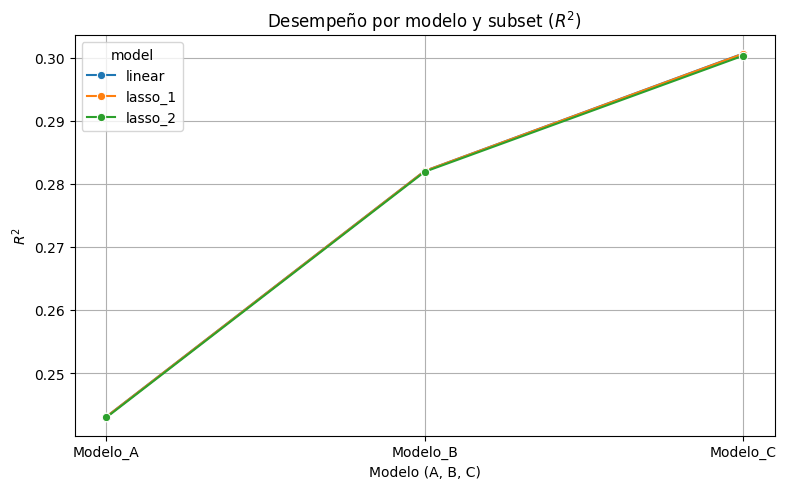

In [172]:
df['subset'] = df_plot['subset'].str.replace('Modelo_', '')

plt.figure(figsize=(8,5))
sns.lineplot(
    data=df_plot,
    x='subset',
    y='r2_val',
    hue='model',
    marker='o'
)

plt.title('Desempeño por modelo y subset ($R^2$)')
plt.xlabel('Modelo (A, B, C)')
plt.ylabel('$R^2$')
plt.grid(True)

plt.tight_layout()
plt.savefig("../results/model_performance_subset.png")
plt.show()

Observamos un patron 

- Modelo A: $R^2\approx 0.24$
- Modelo B: $R^2\approx 0.28$
- Modelo C: $R^2\approx 0.30$

Los coeficientes: 

In [173]:
def compare_coefficients(models_coefs, model_name):
    dfs = []

    for subset in ["Modelo_A", "Modelo_B", "Modelo_C"]:
        df = models_coefs[(model_name, subset)].copy()
        df["subset"] = subset
        dfs.append(df)

    df_all = pd.concat(dfs)

    df_all["feature"] = df_all["feature"].str.replace(".*__", "", regex=True)

    plt.figure(figsize=(10,6))

    sns.barplot(
        data=df_all,
        x="coef",
        y="feature",
        hue="subset"
    )

    plt.title(f"Comparación de coeficientes ({model_name})")
    plt.xlabel("Coeficiente")
    plt.ylabel("Variable")

    plt.tight_layout()
    plt.savefig(f"../results/coefficientes_{model_name}")
    plt.show()

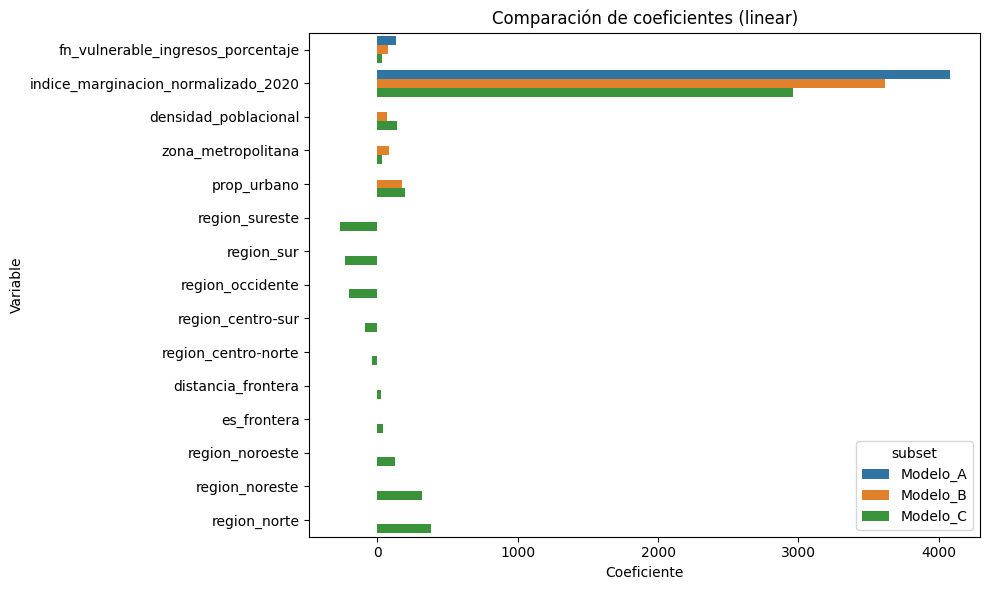

In [174]:
compare_coefficients(models_coefs, 'linear')

Tenemos lo siguiente: 

#### Modelo A (socieconómico)

- `indice_marginacion` &rarr; coeficiente alto y positivo
- `vulnerable_ingresos` &rarr; positivo, menor magnitud

Esto indica que las variables socioecómicas capturan una señal fuerte, lo cual no necesariamente implica causa directa. 


#### ModeloB (+ urbanización)

Cambios importantes:

- `prop_urbano` &rarr; coeficiente positivo alto
- `densidad_poblacional` &rarr; positivo
`zona_metropolitana` &rarr; positivo

Y: 

- `indecia_marginacion` baja de (\~4000 a \~3600)

Parte del efecto socieconómico estaba mediado por la urbanización. 

#### Modelo C (+ geografía)

Cambios relevantes:

- `region` introduce variabilidad importante
- `algunas` regiones con coeficientes negativos, otras positivos
- `distancia_frontera &rarr; efecto pequeño
- `es_frontera` &rarr; efecto positivo moderado

Y:

- `indice_marginacion` baja nuevamente (~2900)

Podemos interpretar estos resultados como que la geografía añade diferencias entre regiones, pero no reemplaza la urbanización y el efecto socieconómico sigue presente, pero reducido.

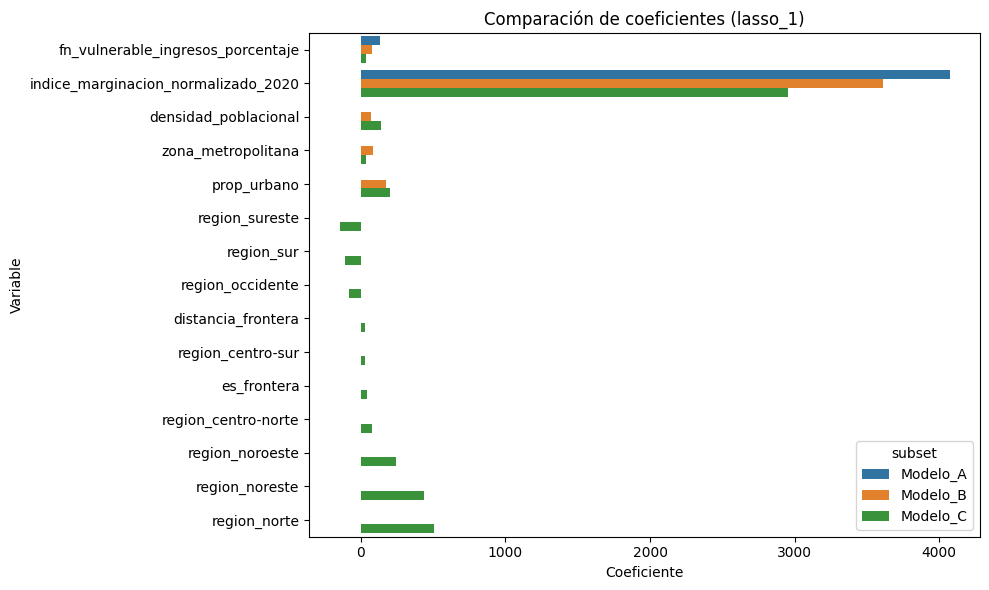

In [175]:
compare_coefficients(models_coefs, 'lasso_1')

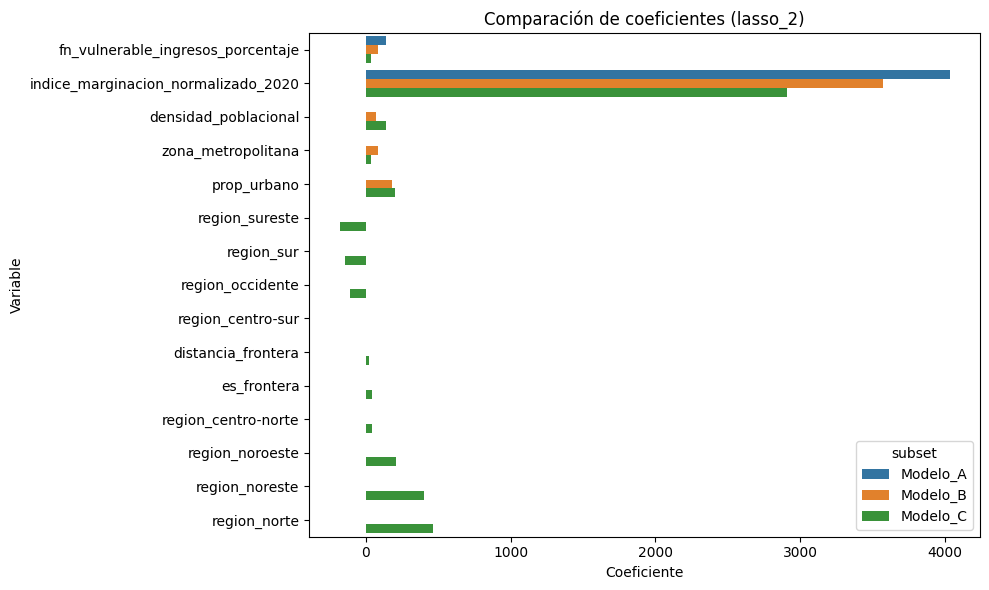

In [177]:
compare_coefficients(models_coefs, 'lasso_2')

El modelo de regularización (Lasso) muestra coeficientes muy similarea a la regresión lineal, algunas variables reducen su magnitud como es de esperarse y en `lasso_2`, algunas regiones geográficas se eliminan por completo (coef = 0). 

Estos resultados sugieren que el modelo es estable, no hay ruido excesivo y las variables principales son robustas. 

## Conclusion

En este análisis se construyeron modelos de regresión lineal para estudiar cómo las variables socioeconómicas se relacionan con la tasa de incidencia delictiva a nivel municipal. Para ello, se incorporaron de forma progresiva variables de urbanización y geografía, con el objetivo de entender mejor el papel de cada grupo de variables.

El análisis exploratorio fue fundamental para guiar estas decisiones. En esta etapa se detectó una alta correlación entre variables socioeconómicas, así como patrones que indicaban que la urbanización podía estar influyendo de manera importante en la incidencia delictiva. Por esta razón, se decidió trabajar con un conjunto reducido de variables representativas y estructurar los modelos en tres niveles (A, B y C), agregando variables de forma progresiva.

También se utilizó una división temporal de los datos (entrenamiento hasta 2018, validación en 2019 y prueba en 2020) para evitar usar información futura durante el entrenamiento (*data leackage*) y así obtener una evaluación más realista del modelo.

En cuanto a los resultados, se observa que las variables socioeconómicas por sí solas logran explicar una parte del fenómeno ($R^2$ cercano a 0.24). Sin embargo, al agregar variables de urbanización, el desempeño mejora de forma clara ($R^2$ cercano a 0.28), lo que indica que el grado de urbanización es un factor importante en la explicación de la incidencia delictiva. Finalmente, al incorporar variables geográficas, el modelo mejora ligeramente ($R^2$ cercano a 0.30), lo que sugiere que también existen diferencias regionales, aunque su impacto es menor.

Estos resultados pueden observarse en la siguiente figura, donde se muestra la evolución del desempeño de los modelos.

![Alt Text](../results/model_performance_subset.png)

El análisis de coeficientes permite entender mejor estas relaciones. En los modelos más simples, las variables socioeconómicas tienen un peso importaante, pero al incluir variables de urbanización, su efecto disminuye. Esto sugiere que parte de la relación entre condiciones socioeconómicas y delitos está influida por el contexto urbano. Al agregar variables geográficas, se observan diferencias entre regiones, lo que indica que el fenómeno no es completamente uniforme en todo el país.

Estas relaciones se pueden observar en las figuras siguientes, donde se muestran los coeficientes de los distintos modelos.

![Alt Text](../results/coefficientes_linear.png)
![Alt Text](../results/coefficientes_lasso_1.png)
![Alt Text](../results/coefficientes_lasso_2.png)

Por otro lado, los modelos con regularización (Lasso) presentan resultados muy similares a la regresión lineal, lo que indica que el conjunto de variables utilizado es consistente y que no hay una dependencia excesiva de variables redundantes.

En general, los resultados sugieren que la incidencia delictiva no depende únicamente de factores socioeconómicos, sino que está fuertemente relacionada con el nivel de urbanización y, en menor medida, con factores geográficos. El enfoque utilizado permitió analizar estos efectos de forma progresiva y obtener una interpretación más clara del problema.

### Limitaciones

Este análisis tiene algunas limitaciones importantes:

- Los modelos lineales no capturan relaciones no lineales, que ya se observaron en el EDA.
- No se modela de forma explícita la dependencia espacial ni temporal entre municipios.
- Algunas variables pueden estar representando fenómenos más complejos (por ejemplo, urbanización), lo quelimita la interpretación directa de los coeficientes.
- Las imputaciones realizadas, aunque justificadas, pueden introducir cierta incertidumbre en los resultados.

### Trabajo futuro

Como siguientes pasos, se podría:

- Probar modelos no lineales (Random Forest, Gradient Boosting) para capturar relaciones más complejas.
- Profundizar en el análisis de interpretabilidad con técnicas más avanzadas como [SHAP](https://shap.readthedocs.io/en/latest/).